# Titanic Survival Prediction with PyTorch

This notebook follows the same PyTorch workflow covered in the reference notes (Appendix A: Dataset, DataLoader, NeuralNetwork, training loop, evaluation, saving the model), applied here to the Titanic dataset.

**Setup used in this notebook (as requested):**
- `num_workers=0` in `DataLoader` (data loading happens in the main process, no worker subprocesses)
- CPU only, no GPU


## 1. Imports and device setup

Same idea as `torch.cuda.is_available()` in the reference notebook, but we force the device to `cpu` explicitly since we were told not to use the GPU.

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print(torch.__version__)
print("CUDA available:", torch.cuda.is_available())

# Force CPU as requested (no GPU)
device = torch.device("cpu")
print("Using device:", device)


2.13.0
CUDA available: False
Using device: cpu


## 2. Load the dataset

Same Titanic dataset commonly used for this kind of exercise (`PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked`).

In [3]:
df = pd.read_csv("/Users/gautam/Downloads/AI/titanic (1).csv")
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [5]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

## 3. Preprocessing

Before we can build tensors (like `X_train`, `y_train` in the reference notebook), the raw Titanic table needs to be turned into pure numeric columns:

1. Fill missing `Age` with the median, missing `Embarked` with the mode.
2. Drop columns that aren't useful as simple numeric features here: `PassengerId`, `Name`, `Ticket`, `Cabin`.
3. Encode `Sex` as 0/1.
4. One-hot encode `Embarked`.
5. Split into train/test, then scale features (mean 0, std 1) — neural nets train much better on scaled inputs.

In [6]:
data = df.copy()

# 1. Handle missing values
data["Age"] = data["Age"].fillna(data["Age"].median())
data["Embarked"] = data["Embarked"].fillna(data["Embarked"].mode()[0])

# 2. Drop columns we are not using as features
data = data.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

# 3. Encode Sex as 0/1
data["Sex"] = data["Sex"].map({"male": 0, "female": 1})

# 4. One-hot encode Embarked
data = pd.get_dummies(data, columns=["Embarked"], drop_first=True)

data.head()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [7]:
feature_cols = [c for c in data.columns if c != "Survived"]
print("Features used:", feature_cols)
print("Number of input features:", len(feature_cols))


Features used: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']
Number of input features: 8


In [8]:
X = data[feature_cols].values.astype(np.float32)
y = data["Survived"].values.astype(np.int64)

# 5. Train / test split, then scale (fit scaler on train only, to avoid leakage)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train).astype(np.float32)
X_test = scaler.transform(X_test).astype(np.float32)

print("X_train:", X_train.shape, " X_test:", X_test.shape)


X_train: (712, 8)  X_test: (179, 8)


## 4. Turn NumPy arrays into tensors

Same as `X_train = torch.tensor([...])`, `y_train = torch.tensor([...])` in the reference notebook.

In [9]:
X_train = torch.tensor(X_train)
y_train = torch.tensor(y_train)
X_test = torch.tensor(X_test)
y_test = torch.tensor(y_test)

print(X_train.shape, X_train.dtype)
print(y_train.shape, y_train.dtype)


torch.Size([712, 8]) torch.float32
torch.Size([712]) torch.int64


## 5. Custom Dataset (same pattern as `ToyDataset`)

In [11]:
class TitanicDataset(Dataset):
    def __init__(self, X, y):
        self.features = X
        self.labels = y

    def __getitem__(self, index):
        one_x = self.features[index]
        one_y = self.labels[index]
        return one_x, one_y

    def __len__(self):
        return self.labels.shape[0]


train_ds = TitanicDataset(X_train, y_train)
test_ds = TitanicDataset(X_test, y_test)

print("train size:", len(train_ds))
print("test size:", len(test_ds))
print("sample item:", train_ds[0])


train size: 712
test size: 179
sample item: (tensor([ 0.8088, -0.7402,  1.6763, -0.4693, -0.4640, -0.4625, -0.2950,  0.6185]), tensor(0))


## 6. DataLoaders

`num_workers=0` -> data loading happens in the main process (no separate worker subprocesses), which is what was asked for here since we're on CPU.

In [12]:
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_ds,
    batch_size=16,
    shuffle=True,
    num_workers=0,
    drop_last=True,
)

test_loader = DataLoader(
    dataset=test_ds,
    batch_size=16,
    shuffle=False,
    num_workers=0,
)

print("Number of train batches:", len(train_loader))
print("Number of test batches:", len(test_loader))


Number of train batches: 44
Number of test batches: 12


## 7. The model (same `NeuralNetwork` pattern)

Same architecture idea as the reference: `torch.nn.Sequential` of `Linear` + `ReLU` layers, ending in a `Linear` layer with no activation (raw logits), sized to `num_inputs` = number of Titanic features and `num_outputs = 2` (died / survived).

In [13]:
class NeuralNetwork(nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super().__init__()

        self.layers = nn.Sequential(
            # 1st hidden layer
            nn.Linear(num_inputs, 30),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(30, 20),
            nn.ReLU(),

            # output layer -> 2 classes: did not survive (0), survived (1)
            nn.Linear(20, num_outputs),
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits


In [14]:
torch.manual_seed(123)

num_inputs = X_train.shape[1]
num_outputs = 2

model = NeuralNetwork(num_inputs, num_outputs).to(device)
print(model)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("Total number of trainable model parameters:", num_params)


NeuralNetwork(
  (layers): Sequential(
    (0): Linear(in_features=8, out_features=30, bias=True)
    (1): ReLU()
    (2): Linear(in_features=30, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=2, bias=True)
  )
)
Total number of trainable model parameters: 932


## 8. Training loop (same pattern as the reference notebook)

Same as before, but this time we also keep track of the **average training loss** and the **average validation loss** for every epoch (validation here = the held-out `test_loader` split), so we can plot a loss curve afterwards.

In [15]:
def compute_avg_loss(model, dataloader):
    model.eval()
    total_loss = 0.0
    total_examples = 0

    with torch.no_grad():
        for features, labels in dataloader:
            features, labels = features.to(device), labels.to(device)
            logits = model(features)
            loss = F.cross_entropy(logits, labels, reduction="sum")
            total_loss += loss.item()
            total_examples += labels.size(0)

    return total_loss / total_examples


def compute_accuracy(model, dataloader):

    model.eval()
    correct = 0.0
    total_examples = 0

    for idx, (features, labels) in enumerate(dataloader):
        features, labels = features.to(device), labels.to(device)

        with torch.no_grad():
            logits = model(features)

        predictions = torch.argmax(logits, dim=1)
        compare = labels == predictions
        correct += torch.sum(compare)
        total_examples += len(compare)

    return (correct / total_examples).item()


In [16]:
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)

num_epochs = 50

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):

    model.train()
    for batch_idx, (features, labels) in enumerate(train_loader):
        features, labels = features.to(device), labels.to(device)

        logits = model(features)

        loss = F.cross_entropy(logits, labels)  # Loss function

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # ---- end of epoch: record avg train / validation loss + accuracy ----
    epoch_train_loss = compute_avg_loss(model, train_loader)
    epoch_val_loss = compute_avg_loss(model, test_loader)
    epoch_train_acc = compute_accuracy(model, train_loader)
    epoch_val_acc = compute_accuracy(model, test_loader)

    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_acc)
    val_accuracies.append(epoch_val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d}"
              f" | Train Loss: {epoch_train_loss:.4f}"
              f" | Val Loss: {epoch_val_loss:.4f}"
              f" | Val Acc: {epoch_val_acc*100:.2f}%")


Epoch: 001/050 | Train Loss: 0.5357 | Val Loss: 0.5494 | Val Acc: 76.54%
Epoch: 005/050 | Train Loss: 0.4180 | Val Loss: 0.4449 | Val Acc: 80.45%
Epoch: 010/050 | Train Loss: 0.4053 | Val Loss: 0.4372 | Val Acc: 81.56%
Epoch: 015/050 | Train Loss: 0.3882 | Val Loss: 0.4093 | Val Acc: 80.45%
Epoch: 020/050 | Train Loss: 0.3984 | Val Loss: 0.4280 | Val Acc: 79.33%
Epoch: 025/050 | Train Loss: 0.3855 | Val Loss: 0.4148 | Val Acc: 79.89%
Epoch: 030/050 | Train Loss: 0.3714 | Val Loss: 0.4115 | Val Acc: 83.24%
Epoch: 035/050 | Train Loss: 0.3787 | Val Loss: 0.4132 | Val Acc: 81.01%
Epoch: 040/050 | Train Loss: 0.3654 | Val Loss: 0.4148 | Val Acc: 83.80%
Epoch: 045/050 | Train Loss: 0.3660 | Val Loss: 0.4185 | Val Acc: 80.45%
Epoch: 050/050 | Train Loss: 0.3587 | Val Loss: 0.4119 | Val Acc: 84.36%


## 9. Final evaluation

In [17]:
train_acc = compute_accuracy(model, train_loader)
test_acc = compute_accuracy(model, test_loader)

print(f"Train accuracy: {train_acc*100:.2f}%")
print(f"Test accuracy:  {test_acc*100:.2f}%")


Train accuracy: 85.09%
Test accuracy:  84.36%


## 9b. Loss and accuracy curves

Now that `train_losses`, `val_losses`, `train_accuracies`, and `val_accuracies` were recorded every epoch during training, we can plot them to see how the model learned over time and check for overfitting (train and val curves drifting apart).

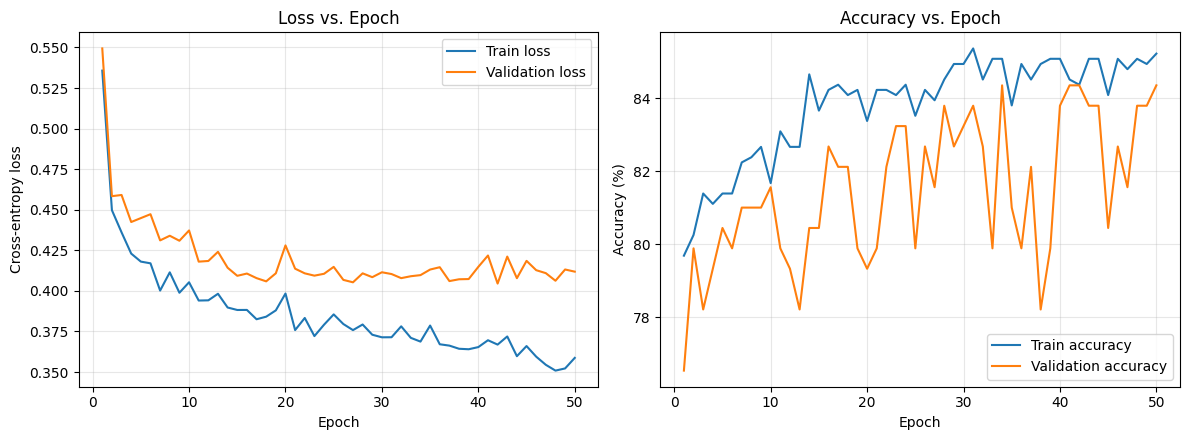

In [18]:
import matplotlib.pyplot as plt

epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# --- Loss curve ---
axes[0].plot(epochs_range, train_losses, label="Train loss")
axes[0].plot(epochs_range, val_losses, label="Validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss")
axes[0].set_title("Loss vs. Epoch")
axes[0].legend()
axes[0].grid(alpha=0.3)

# --- Accuracy curve ---
axes[1].plot(epochs_range, [a * 100 for a in train_accuracies], label="Train accuracy")
axes[1].plot(epochs_range, [a * 100 for a in val_accuracies], label="Validation accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_title("Accuracy vs. Epoch")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 10. Try it on a few individual passengers

Same idea as the single-row forward pass (`out = model(X)`) in the reference notebook, plus `softmax` to turn logits into survival probabilities.

In [19]:
model.eval()
with torch.no_grad():
    sample_X = X_test[:10]
    logits = model(sample_X)
    probas = torch.softmax(logits, dim=1)
    preds = torch.argmax(probas, dim=1)

for i in range(10):
    print(f"Actual: {y_test[i].item()} | Predicted: {preds[i].item()} "
          f"| P(survive) = {probas[i,1].item():.2f}")


Actual: 0 | Predicted: 0 | P(survive) = 0.06
Actual: 1 | Predicted: 1 | P(survive) = 0.98
Actual: 1 | Predicted: 0 | P(survive) = 0.06
Actual: 0 | Predicted: 1 | P(survive) = 0.91
Actual: 1 | Predicted: 1 | P(survive) = 0.69
Actual: 0 | Predicted: 0 | P(survive) = 0.36
Actual: 0 | Predicted: 0 | P(survive) = 0.07
Actual: 0 | Predicted: 0 | P(survive) = 0.07
Actual: 0 | Predicted: 0 | P(survive) = 0.08
Actual: 1 | Predicted: 1 | P(survive) = 0.99


## 11. Save the trained model

Same as `torch.save(model.state_dict(), "model.pth")` in the reference notebook.

In [20]:
torch.save(model.state_dict(), "titanic_model.pth")
print("Saved model to titanic_model.pth")


Saved model to titanic_model.pth


In [21]:
# Reloading it back needs an identically-shaped model first, same as the reference notebook
loaded_model = NeuralNetwork(num_inputs, num_outputs)
loaded_model.load_state_dict(torch.load("titanic_model.pth", weights_only=True, map_location=device))
loaded_model.eval()

print("Reloaded model test accuracy:", compute_accuracy(loaded_model, test_loader))


Reloaded model test accuracy: 0.8435754179954529
